In [ ]:
import osmnx as ox
import pandas as pd
import shapely
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import esda
from libpysal import weights
from pysal.model import spreg
import statsmodels.api as sm
from splot.esda import lisa_cluster

In [10]:
G = ox.load_graphml(
    "../data/processed/paris_simplified_results/paris_cleaned_multigraph.graphml"
)
gdf_edges = ox.graph_to_gdfs(G, edges=True, nodes=False)
gdf_edges = gdf_edges[["geometry", "length", "built"]]

In [12]:
gdf_iris = gpd.read_file(
    "../data/processed/paris_official_data/paris_dem_iris_condensed_enriched.gpkg"
)

In [13]:
gdf_iris = gdf_iris.to_crs(gdf_edges.crs)

In [19]:
gdf_vote_sta = gpd.read_file(
    "../data/processed/paris_official_data/paris_vote_list.gpkg"
)

In [22]:
gdf_vote_sta = gdf_vote_sta.to_crs(gdf_edges.crs)

In [30]:
gdf_vote_arr = gpd.read_file(
    "../data/processed/paris_official_data/paris_vote_arr.gpkg"
)

In [31]:
gdf_vote_arr = gdf_vote_arr.to_crs(gdf_edges.crs)

In [14]:
BUSINESSES_TO_COUNT = [
    "Alimentaire",
    "Grand magasin",
    "Hôtel",
    "Non Alimentaire",
    "Restauration",
    "Service commercial",
]

In [ ]:
gdf_iris_edges = gdf_iris.sjoin(gdf_edges, how="left", predicate="intersects")
results_dict = {}
for idx, row in gdf_iris_edges.iterrows():
    if isinstance(row["built"], str):
        length = shapely.intersection(
            row["geometry"], gdf_edges.loc[row["u"], row["v"], row["key"]]["geometry"]
        ).length
    else:
        length = 0
    planned = 0
    before = 0
    built = 0
    if row["built"] == "No":
        planned += length
    elif row["built"] == "2021-01-01":
        before += length
    else:
        planned += length
        built += length
    if idx not in results_dict.keys():
        results_dict[idx] = {
            "length_before_2021": before,
            "length_planned": planned,
            "length_built": built,
        }
    else:
        results_dict[idx]["length_before_2021"] += before
        results_dict[idx]["length_planned"] += planned
        results_dict[idx]["length_built"] += built
df = pd.DataFrame.from_dict(results_dict, orient="index")
gdf_iris_res = gdf_iris.merge(df, left_index=True, right_index=True)
gdf_iris_res["length_accomplished_share"] = (
    gdf_iris_res["length_built"] / gdf_iris_res["length_planned"]
)
gdf_iris_res["length_final"] = (
    gdf_iris_res["length_before_2021"] + gdf_iris_res["length_planned"]
)
for col in [
    "length_before_2021",
    "length_planned",
    "length_built",
    "length_final",
]:
    gdf_iris_res[col + "_norm"] = (gdf_iris_res[col] / 10**3) / (
        gdf_iris_res["geometry"].area / 10**6
    )

In [116]:
gdf_iris.drop(
    ["CODE_IRIS", "geometry"]
    + BUSINESSES_TO_COUNT
    + [bus + "_density" for bus in BUSINESSES_TO_COUNT],
    axis=1,
).corr()

,population,pop_density,active_population,median_income,poverty_rate,commuter_cyclist_share,commuter_driver_share,LUD_share,LUG_share
population,1.000000,0.448011,0.936224,-0.278526,0.179495,-0.004781,0.074956,-0.185402,0.065159
pop_density,0.448011,1.000000,0.467650,-0.280120,0.167829,0.081091,-0.155952,-0.163286,0.348464
active_population,0.936224,0.467650,1.000000,-0.221922,0.078798,0.065648,-0.026419,-0.227562,0.134416
median_income,-0.278526,-0.280120,-0.221922,1.000000,-0.823132,0.009482,0.269896,0.536528,-0.457109
poverty_rate,0.179495,0.167829,0.078798,-0.823132,1.000000,-0.097136,-0.100440,-0.330439,0.261230
commuter_cyclist_share,-0.004781,0.081091,0.065648,0.009482,-0.097136,1.000000,-0.263286,-0.210663,0.278606
commuter_driver_share,0.074956,-0.155952,-0.026419,0.269896,-0.100440,-0.263286,1.000000,0.186023,-0.688710
LUD_share,-0.185402,-0.163286,-0.227562,0.536528,-0.330439,-0.210663,0.186023,1.000000,-0.299089
LUG_share,0.065159,0.348464,0.134416,-0.457109,0.261230,0.278606,-0.688710,-0.299089,1.000000


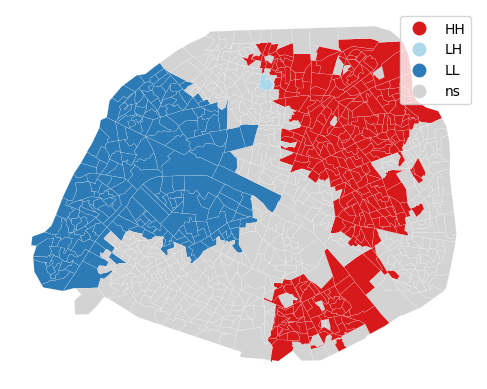

In [24]:
w = weights.Queen.from_dataframe(gdf_vote_sta, use_index=False)
w.transform = "R"
moran = esda.moran.Moran_Local(gdf_vote_sta["LUG_share"], w)
fig = lisa_cluster(moran, gdf_vote_sta)
plt.show()

In [32]:
gdf_vote_arr_edges = gdf_vote_arr.sjoin(gdf_edges, how="left", predicate="intersects")
results_dict = {}
for idx, row in gdf_vote_arr_edges.iterrows():
    if isinstance(row["built"], str):
        length = shapely.intersection(
            row["geometry"], gdf_edges.loc[row["u"], row["v"], row["key"]]["geometry"]
        ).length
    else:
        length = 0
    planned = 0
    before = 0
    built = 0
    if row["built"] == "No":
        planned += length
    elif row["built"] == "2021-01-01":
        before += length
    else:
        planned += length
        built += length
    if idx not in results_dict.keys():
        results_dict[idx] = {
            "length_before_2021": before,
            "length_planned": planned,
            "length_built": built,
        }
    else:
        results_dict[idx]["length_before_2021"] += before
        results_dict[idx]["length_planned"] += planned
        results_dict[idx]["length_built"] += built
df = pd.DataFrame.from_dict(results_dict, orient="index")
gdf_vote_arr_res = gdf_vote_arr.merge(df, left_index=True, right_index=True)
gdf_vote_arr_res["length_accomplished_share"] = (
    gdf_vote_arr_res["length_built"] / gdf_vote_arr_res["length_planned"]
)
gdf_vote_arr_res["length_final"] = (
    gdf_vote_arr_res["length_before_2021"] + gdf_vote_arr_res["length_planned"]
)
for col in [
    "length_before_2021",
    "length_planned",
    "length_built",
    "length_final",
]:
    gdf_vote_arr_res[col + "_norm"] = (gdf_vote_arr_res[col] / 10**3) / (
        gdf_vote_arr_res["geometry"].area / 10**6
    )

<Axes: >

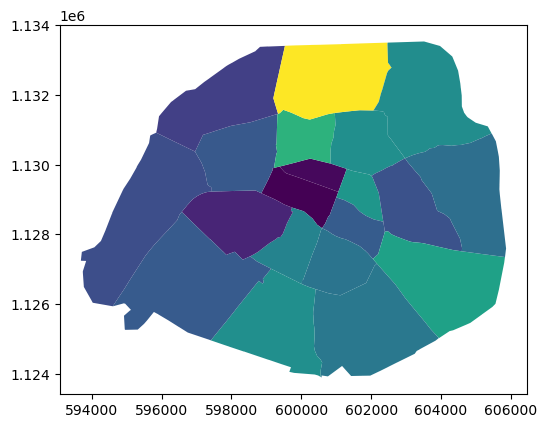

In [33]:
gdf_vote_arr_res.plot(column="length_accomplished_share")

In [111]:
gdf_vote_arr_res[
    [
        "LUD_share",
        "LUG_share",
        "length_accomplished_share",
        "length_before_2021_norm",
        "length_planned_norm",
    ]
].corr()

,LUD_share,LUG_share,length_accomplished_share,length_before_2021_norm,length_planned_norm
LUD_share,1.000000,-0.827120,-0.433991,-0.403327,0.194406
LUG_share,-0.827120,1.000000,0.389051,0.562668,-0.399305
length_accomplished_share,-0.433991,0.389051,1.000000,0.078997,-0.313970
length_before_2021_norm,-0.403327,0.562668,0.078997,1.000000,-0.534399
length_planned_norm,0.194406,-0.399305,-0.313970,-0.534399,1.000000


In [ ]:
endog = gdf_vote_arr_res["length_accomplished_share"]
exog = sm.add_constant(gdf_vote_arr_res["LUD_share"])
mod = sm.OLS(endog, exog)
results = mod.fit()
print(results.summary())

                                OLS Regression Results                               
Dep. Variable:     length_accomplished_share   R-squared:                       0.188
Model:                                   OLS   Adj. R-squared:                  0.143
Method:                        Least Squares   F-statistic:                     4.177
Date:                       Thu, 09 Apr 2026   Prob (F-statistic):             0.0559
Time:                               10:48:47   Log-Likelihood:                 7.1600
No. Observations:                         20   AIC:                            -10.32
Df Residuals:                             18   BIC:                            -8.329
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

Text(0, 0.5, 'Length accomplished')

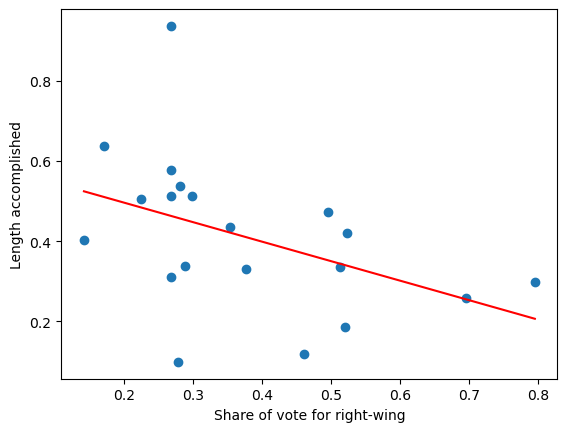

In [59]:
fig, ax = plt.subplots()
ax.scatter(
    gdf_vote_arr_res["LUD_share"].values,
    gdf_vote_arr_res["length_accomplished_share"].values,
)
x = np.linspace(
    gdf_vote_arr_res["LUD_share"].min(), gdf_vote_arr_res["LUD_share"].max()
)
y = results.params["const"] + results.params["LUD_share"] * x
ax.plot(x, y, color="red")
ax.set_xlabel("Share of vote for right-wing")
ax.set_ylabel("Length accomplished")

In [60]:
gdf_vote_sta_edges = gdf_vote_sta.sjoin(gdf_edges, how="left", predicate="intersects")
results_dict = {}
for idx, row in gdf_vote_sta_edges.iterrows():
    if isinstance(row["built"], str):
        length = shapely.intersection(
            row["geometry"], gdf_edges.loc[row["u"], row["v"], row["key"]]["geometry"]
        ).length
    else:
        length = 0
    planned = 0
    before = 0
    built = 0
    if row["built"] == "No":
        planned += length
    elif row["built"] == "2021-01-01":
        before += length
    else:
        planned += length
        built += length
    if idx not in results_dict.keys():
        results_dict[idx] = {
            "length_before_2021": before,
            "length_planned": planned,
            "length_built": built,
        }
    else:
        results_dict[idx]["length_before_2021"] += before
        results_dict[idx]["length_planned"] += planned
        results_dict[idx]["length_built"] += built
df = pd.DataFrame.from_dict(results_dict, orient="index")
gdf_vote_sta_res = gdf_vote_sta.merge(df, left_index=True, right_index=True)
gdf_vote_sta_res["length_accomplished_share"] = (
    gdf_vote_sta_res["length_built"] / gdf_vote_sta_res["length_planned"]
)
gdf_vote_sta_res["length_final"] = (
    gdf_vote_sta_res["length_before_2021"] + gdf_vote_sta_res["length_planned"]
)
for col in [
    "length_before_2021",
    "length_planned",
    "length_built",
    "length_final",
]:
    gdf_vote_sta_res[col + "_norm"] = (gdf_vote_sta_res[col] / 10**3) / (
        gdf_vote_sta_res["geometry"].area / 10**6
    )

In [64]:
gdf_vote_sta_res_filt = gdf_vote_sta_res[
    gdf_vote_sta_res["length_accomplished_share"].notna()
]
endog = gdf_vote_sta_res_filt["length_accomplished_share"]
exog = sm.add_constant(gdf_vote_sta_res_filt["LUD_share"])
mod = sm.OLS(endog, exog)
results = mod.fit()
print(results.summary())

                                OLS Regression Results                               
Dep. Variable:     length_accomplished_share   R-squared:                       0.044
Model:                                   OLS   Adj. R-squared:                  0.042
Method:                        Least Squares   F-statistic:                     26.61
Date:                       Thu, 09 Apr 2026   Prob (F-statistic):           3.43e-07
Time:                               10:51:05   Log-Likelihood:                -332.65
No. Observations:                        582   AIC:                             669.3
Df Residuals:                            580   BIC:                             678.0
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

Text(0, 0.5, 'Length accomplished')

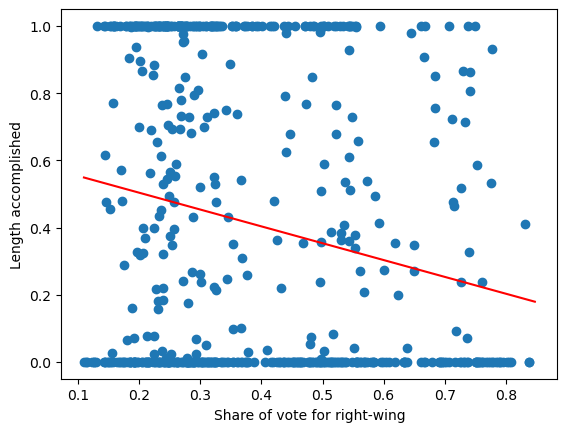

In [65]:
fig, ax = plt.subplots()
ax.scatter(
    gdf_vote_sta_res["LUD_share"].values,
    gdf_vote_sta_res["length_accomplished_share"].values,
)
x = np.linspace(
    gdf_vote_sta_res["LUD_share"].min(), gdf_vote_sta_res["LUD_share"].max()
)
y = results.params["const"] + results.params["LUD_share"] * x
ax.plot(x, y, color="red")
ax.set_xlabel("Share of vote for right-wing")
ax.set_ylabel("Length accomplished")

In [208]:
share = {}
total = gdf_vote_sta["NB_EXPRIM"].sum()
for label in gdf_vote_sta.columns[:9]:
    share[label] = round(100 * (gdf_vote_sta[label].sum() / total), 1)
share

{'LDIV': np.float64(0.0),
 'LDVC': np.float64(1.7),
 'LDVD': np.float64(0.4),
 'LFI': np.float64(1.0),
 'LRN': np.float64(0.0),
 'LUC': np.float64(12.8),
 'LUD': np.float64(36.6),
 'LUG': np.float64(47.3),
 'LVEC': np.float64(0.1)}

In [66]:
gdf_vote_sta_res_filt["length_accomplished_share_binary"] = gdf_vote_sta_res_filt[
    "length_accomplished_share"
].apply(lambda x: 1 if x >= 0.5 else 0)

/Users/clse/miniforge3/envs/orderbike/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [96]:
model = sm.Logit(
    gdf_vote_sta_res_filt["length_accomplished_share_binary"],
    sm.add_constant(gdf_vote_sta_res_filt["LUD_share"]),
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.657740
         Iterations 5
                                  Logit Regression Results                                  
Dep. Variable:     length_accomplished_share_binary   No. Observations:                  582
Model:                                        Logit   Df Residuals:                      580
Method:                                         MLE   Df Model:                            1
Date:                              Thu, 09 Apr 2026   Pseudo R-squ.:                 0.02677
Time:                                      11:06:03   Log-Likelihood:                -382.80
converged:                                     True   LL-Null:                       -393.33
Covariance Type:                          nonrobust   LLR p-value:                 4.459e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

(array([278.,   7.,  19.,  24.,  17.,  19.,  14.,  20.,  13., 171.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

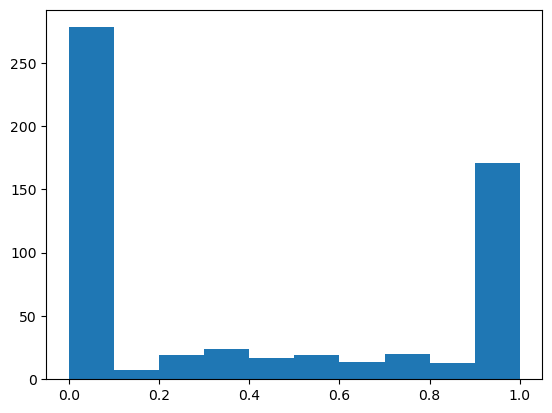

In [73]:
fig, ax = plt.subplots()
ax.hist(gdf_vote_sta_res_filt["length_accomplished_share"].values)

(array([345.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 237.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

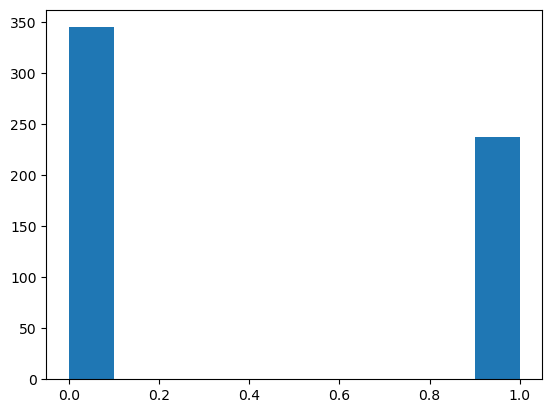

In [72]:
fig, ax = plt.subplots()
ax.hist(gdf_vote_sta_res_filt["length_accomplished_share_binary"].values)

Text(0, 0.5, 'Length accomplished')

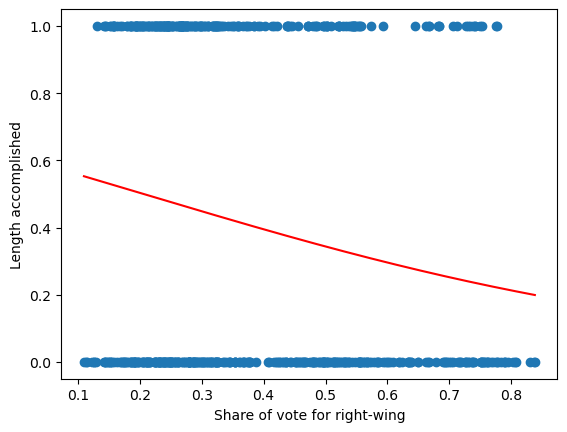

In [101]:
fig, ax = plt.subplots()
ax.scatter(
    gdf_vote_sta_res_filt["LUD_share"].values,
    gdf_vote_sta_res_filt["length_accomplished_share_binary"].values,
)
x = np.linspace(
    gdf_vote_sta_res_filt["LUD_share"].min(),
    gdf_vote_sta_res_filt["LUD_share"].max(),
    num=len(gdf_vote_sta_res_filt),
)
ax.plot(x, model.predict(sm.add_constant(x)), color="red")
ax.set_xlabel("Share of vote for right-wing")
ax.set_ylabel("Length accomplished")

In [108]:
dependent = "length_accomplished_share"
independents = ["LUD_share"]
w = weights.Queen.from_dataframe(gdf_vote_arr_res, use_index=False)
w.transform = "R"
# Fit spatial lag model with `spreg`
# (GMM estimation)
m8 = spreg.GM_Lag(
    # Dependent variable
    gdf_vote_arr_res[[dependent]].values,
    # Independent variables
    gdf_vote_arr_res[independents].values,
    # Spatial weights matrix
    w=w,
    # Dependent variable name
    name_y=dependent,
    # Independent variables names
    name_x=independents,
)
print(m8.summary)

GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :length_accomplished_share                Number of Observations:          20
Mean dependent var  :      0.4115                Number of Variables   :           3
S.D. dependent var  :      0.1926                Degrees of Freedom    :          17
Pseudo R-squared    :      0.1598
Spatial Pseudo R-squared:  0.1989

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.75472         0.39536         1.90896         0.05627
           LUD_share        -0.53438         0.25659        -2.08264     

In [105]:
dependent = "length_accomplished_share_binary"
independents = ["LUD_share"]
w = weights.Queen.from_dataframe(gdf_vote_sta_res_filt)
w.transform = "R"
# Fit spatial lag model with `spreg`
# (GMM estimation)
m8 = spreg.GM_Lag(
    # Dependent variable
    gdf_vote_sta_res_filt[[dependent]].values,
    # Independent variables
    gdf_vote_sta_res_filt[independents].values,
    # Spatial weights matrix
    w=w,
    # Dependent variable name
    name_y=dependent,
    # Independent variables names
    name_x=independents,
)
print(m8.summary)

/var/folders/mb/_ysy1pzs13qgnh9b942_7lkh0000gn/T/ipykernel_5066/3653078660.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.Queen.from_dataframe(gdf_vote_sta_res_filt)


GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :length_accomplished_share_binary                Number of Observations:         582
Mean dependent var  :      0.4072                Number of Variables   :           3
S.D. dependent var  :      0.4917                Degrees of Freedom    :         579
Pseudo R-squared    :      0.3351
Spatial Pseudo R-squared: omitted due to rho outside the boundary (-1, 1).

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        -0.04036         0.31109        -0.12974         0.89677
           LUD_share     

In [ ]:
# from https://medium.com/@1998ameya/introduction-to-spatial-smoothing-with-python-4eaa8db6279c
from scipy.spatial import KDTree

gdf_iris_res["centroid"] = gdf_iris_res.geometry.centroid
centroids = np.array([[point.x, point.y] for point in gdf_iris_res.centroid])
kdtree = KDTree(centroids)


def spatial_smoothing_gaussian(values, centroids, k=10, bandwidth=0.1):
    smoothed_values = np.zeros_like(values)
    for i, centroid in enumerate(centroids):
        distances, indices = kdtree.query(centroid, k=k)
        weights = np.exp(-(distances**2) / (2 * bandwidth**2))
        smoothed_values[i] = np.sum(
            [val * w for val, w in zip(values[indices], weights) if not np.isnan(val)]
        ) / np.sum([w for val, w in zip(values[indices], weights) if not np.isnan(val)])
    return smoothed_values


gdf_iris_res["length_before_2021_norm_smoothed"] = spatial_smoothing_gaussian(
    gdf_iris_res["length_before_2021_norm"].values, centroids, k=20, bandwidth=1
)

In [152]:
gdf_vote_sta_res["centroid"] = gdf_vote_sta_res.geometry.centroid
centroids = np.array([[point.x, point.y] for point in gdf_vote_sta_res.centroid])
kdtree = KDTree(centroids)
gdf_vote_sta_res["length_accomplished_share_smoothed"] = spatial_smoothing_gaussian(
    gdf_vote_sta_res["length_accomplished_share"].values, centroids, k=20, bandwidth=200
)

In [153]:
gdf_vote_sta_res

,LDIV,LDVC,LDVD,LFI,LRN,LUC,LUD,LUG,LVEC,NB_BLANC,...,length_planned,length_built,length_accomplished_share,length_final,length_before_2021_norm,length_planned_norm,length_built_norm,length_final_norm,centroid,length_accomplished_share_smoothed
0,0,0,0,0,0,94,440,99,0,6,...,77.451345,0.000000,0.000000,77.451345,0.000000,1.258393,0.000000,1.258393,POINT (597282.29 1131267.009),0.027297
1,0,0,0,0,0,54,154,227,0,2,...,69.667422,24.442841,0.350850,69.667422,0.000000,1.854586,0.650682,1.854586,POINT (601762.396 1124430.322),0.688726
2,0,0,0,0,0,66,123,269,0,8,...,223.923256,163.886319,0.731886,223.923256,0.000000,3.523331,2.578677,3.523331,POINT (601121.158 1130820.24),0.677617
3,0,0,0,0,0,95,426,94,0,5,...,932.375273,0.000000,0.000000,932.375273,0.000000,8.132658,0.000000,8.132658,POINT (597934.211 1131377.195),0.156317
4,0,0,0,0,0,54,286,217,0,11,...,622.372410,240.155852,0.385872,1070.355196,0.799537,1.110778,0.428618,1.910315,POINT (595268.425 1126327.552),0.360065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,0,35,0,0,0,0,106,336,0,11,...,216.233098,184.585717,0.853642,216.233098,0.000000,4.157537,3.549049,4.157537,POINT (604824.106 1130688.791),0.523769
893,0,63,0,0,0,40,178,204,0,10,...,129.937087,13.020988,0.100210,129.937087,0.000000,4.859196,0.486940,4.859196,POINT (598589.386 1125568.614),0.378424
894,0,79,0,0,0,54,172,310,0,4,...,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,POINT (599457.151 1125178.495),0.632500
895,0,0,0,0,0,66,312,196,0,6,...,279.151272,259.135896,0.928299,279.151272,0.000000,5.265199,4.887680,5.265199,POINT (597776.774 1126078.359),0.614760


<Axes: >

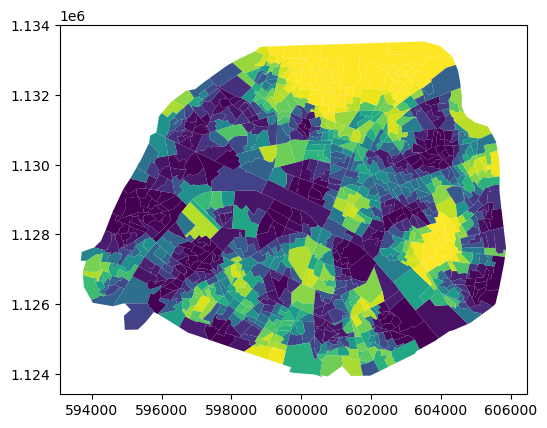

In [154]:
gdf_vote_sta_res.plot(column="length_accomplished_share_smoothed")

In [157]:
endog = gdf_vote_sta_res["length_accomplished_share_smoothed"]
exog = sm.add_constant(gdf_vote_sta_res["LUD_share"])
mod = sm.OLS(endog, exog)
results = mod.fit()
print(results.summary())

                                    OLS Regression Results                                    
Dep. Variable:     length_accomplished_share_smoothed   R-squared:                       0.090
Model:                                            OLS   Adj. R-squared:                  0.089
Method:                                 Least Squares   F-statistic:                     89.04
Date:                                Thu, 09 Apr 2026   Prob (F-statistic):           3.24e-20
Time:                                        15:11:44   Log-Likelihood:                -278.26
No. Observations:                                 897   AIC:                             560.5
Df Residuals:                                     895   BIC:                             570.1
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                 coef    std err          t      P

Text(0, 0.5, 'Length accomplished')

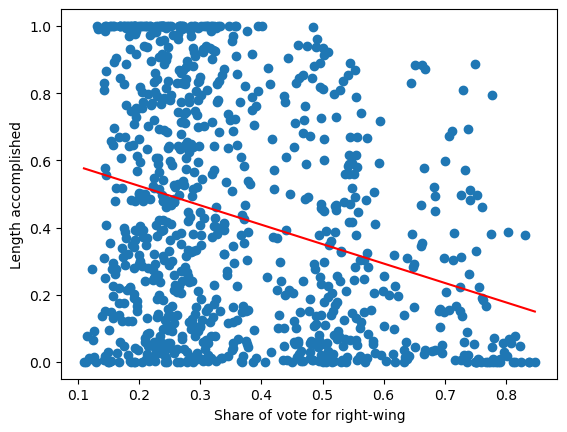

In [158]:
fig, ax = plt.subplots()
ax.scatter(
    gdf_vote_sta_res["LUD_share"].values,
    gdf_vote_sta_res["length_accomplished_share_smoothed"].values,
)
x = np.linspace(
    gdf_vote_sta_res["LUD_share"].min(), gdf_vote_sta_res["LUD_share"].max()
)
y = results.params["const"] + results.params["LUD_share"] * x
ax.plot(x, y, color="red")
ax.set_xlabel("Share of vote for right-wing")
ax.set_ylabel("Length accomplished")

In [159]:
dependent = "length_accomplished_share_smoothed"
independents = ["LUD_share"]
w = weights.Queen.from_dataframe(gdf_vote_sta_res)
w.transform = "R"
# Fit spatial lag model with `spreg`
# (GMM estimation)
m8 = spreg.GM_Lag(
    # Dependent variable
    gdf_vote_sta_res[[dependent]].values,
    # Independent variables
    gdf_vote_sta_res[independents].values,
    # Spatial weights matrix
    w=w,
    # Dependent variable name
    name_y=dependent,
    # Independent variables names
    name_x=independents,
)
print(m8.summary)

GM_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :length_accomplished_share_smoothed                Number of Observations:         897
Mean dependent var  :      0.4246                Number of Variables   :           3
S.D. dependent var  :      0.3462                Degrees of Freedom    :         894
Pseudo R-squared    :      0.8304
Spatial Pseudo R-squared:  0.1111

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.05895         0.08962         0.65777         0.51069
           LUD_share        -0.04597         0.08619        -0.5

/var/folders/mb/_ysy1pzs13qgnh9b942_7lkh0000gn/T/ipykernel_5066/497314146.py:3: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.Queen.from_dataframe(gdf_vote_sta_res)


In [160]:
gdf_vote_sta_res["length_accomplished_share_smoothed_binary"] = gdf_vote_sta_res[
    "length_accomplished_share_smoothed"
].apply(lambda x: 1 if x >= 0.5 else 0)

In [163]:
model = sm.Logit(
    gdf_vote_sta_res["length_accomplished_share_smoothed_binary"],
    sm.add_constant(gdf_vote_sta_res["LUD_share"]),
).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.636841
         Iterations 5
                                       Logit Regression Results                                      
Dep. Variable:     length_accomplished_share_smoothed_binary   No. Observations:                  897
Model:                                                 Logit   Df Residuals:                      895
Method:                                                  MLE   Df Model:                            1
Date:                                       Thu, 09 Apr 2026   Pseudo R-squ.:                 0.04854
Time:                                               15:16:31   Log-Likelihood:                -571.25
converged:                                              True   LL-Null:                       -600.39
Covariance Type:                                   nonrobust   LLR p-value:                 2.272e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
---

Text(0, 0.5, 'Length accomplished')

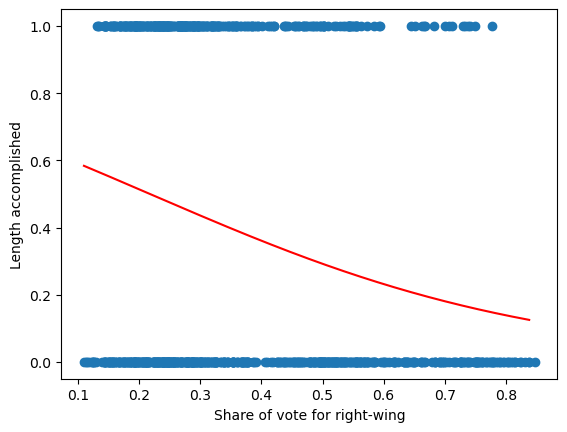

In [164]:
fig, ax = plt.subplots()
ax.scatter(
    gdf_vote_sta_res["LUD_share"].values,
    gdf_vote_sta_res["length_accomplished_share_smoothed_binary"].values,
)
x = np.linspace(
    gdf_vote_sta_res_filt["LUD_share"].min(),
    gdf_vote_sta_res_filt["LUD_share"].max(),
    num=len(gdf_vote_sta_res_filt),
)
ax.plot(x, model.predict(sm.add_constant(x)), color="red")
ax.set_xlabel("Share of vote for right-wing")
ax.set_ylabel("Length accomplished")

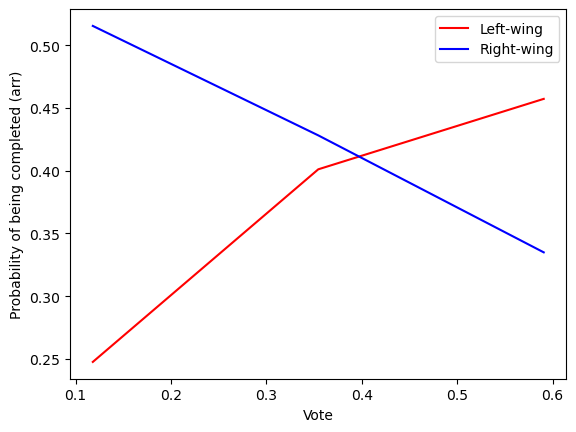

In [203]:
hist, bin_edges = np.histogram(gdf_vote_arr_res["LUG_share"].values, bins=3)
res = [
    gdf_vote_arr_res[
        (gdf_vote_arr_res["LUG_share"] >= bin_edges[i])
        & (gdf_vote_arr_res["LUG_share"] < bin_edges[i + 1])
    ]["length_accomplished_share"].mean()
    for i in range(len(bin_edges) - 1)
]
fig, ax = plt.subplots()
ax.plot(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    label="Left-wing",
    color="red",
)
ax.set_xlabel("Vote")
ax.set_ylabel("Probability of being completed (arr)")
res = [
    gdf_vote_arr_res[
        (gdf_vote_arr_res["LUD_share"] >= bin_edges[i])
        & (gdf_vote_arr_res["LUD_share"] < bin_edges[i + 1])
    ]["length_accomplished_share"].mean()
    for i in range(len(bin_edges) - 1)
]
ax.plot(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    label="Right-wing",
    color="blue",
)
ax.legend()

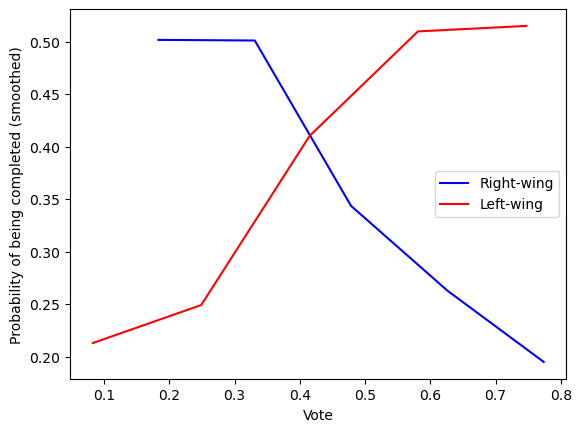

In [205]:
hist, bin_edges = np.histogram(gdf_vote_sta_res["LUD_share"].values, bins=5)
res = [
    gdf_vote_sta_res[
        (gdf_vote_sta_res["LUD_share"] >= bin_edges[i])
        & (gdf_vote_sta_res["LUD_share"] < bin_edges[i + 1])
    ]["length_accomplished_share_smoothed"].mean()
    for i in range(len(bin_edges) - 1)
]
fig, ax = plt.subplots()
ax.plot(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    label="Right-wing",
    color="blue",
)
ax.set_xlabel("Vote")
ax.set_ylabel("Probability of being completed (smoothed)")
hist, bin_edges = np.histogram(gdf_vote_sta_res["LUG_share"].values, bins=5)
res = [
    gdf_vote_sta_res[
        (gdf_vote_sta_res["LUG_share"] >= bin_edges[i])
        & (gdf_vote_sta_res["LUG_share"] < bin_edges[i + 1])
    ]["length_accomplished_share_smoothed"].mean()
    for i in range(len(bin_edges) - 1)
]
ax.plot(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    label="Left-wing",
    color="red",
)
ax.legend()

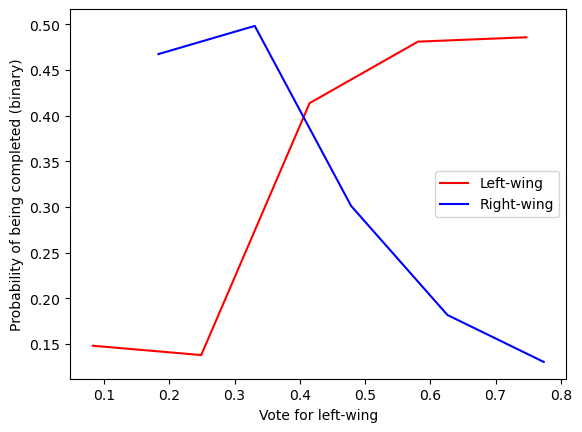

In [206]:
hist, bin_edges = np.histogram(gdf_vote_sta_res["LUG_share"].values, bins=5)
res = [
    gdf_vote_sta_res[
        (gdf_vote_sta_res["LUG_share"] >= bin_edges[i])
        & (gdf_vote_sta_res["LUG_share"] < bin_edges[i + 1])
    ]["length_accomplished_share_smoothed_binary"].mean()
    for i in range(len(bin_edges) - 1)
]
fig, ax = plt.subplots()
ax.plot(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    label="Left-wing",
    color="red",
)
ax.set_xlabel("Vote for left-wing")
ax.set_ylabel("Probability of being completed (binary)")
hist, bin_edges = np.histogram(gdf_vote_sta_res["LUD_share"].values, bins=5)
res = [
    gdf_vote_sta_res[
        (gdf_vote_sta_res["LUD_share"] >= bin_edges[i])
        & (gdf_vote_sta_res["LUD_share"] < bin_edges[i + 1])
    ]["length_accomplished_share_smoothed_binary"].mean()
    for i in range(len(bin_edges) - 1)
]
ax.plot(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    label="Right-wing",
    color="blue",
)
ax.legend()